# Исследование объявлений о продаже квартир

В вашем распоряжении данные сервиса Яндекс Недвижимость — архив объявлений о продаже квартир в Санкт-Петербурге и соседних населённых пунктах за несколько лет. Вам нужно научиться определять рыночную стоимость объектов недвижимости. Для этого проведите исследовательский анализ данных и установите параметры, влияющие на цену объектов. Это позволит построить автоматизированную систему: она отследит аномалии и мошенническую деятельность.

По каждой квартире на продажу доступны два вида данных. Первые вписаны пользователем, вторые — получены автоматически на основе картографических данных. Например, расстояние до центра, аэропорта и других объектов — эти данные автоматически получены из геосервисов. Количество парков и водоёмов также заполняется без участия пользователя.

Цель работы
Целью данного проекта является определение рыночной стоимости объектов недвижимости в Санкт-Петербурге и Ленинградской области на основе данных сервиса Яндекс Недвижимость. Для этого требуется провести исследовательский анализ данных, выявить ключевые параметры, влияющие на цену объектов.

План работы
Предобработка данных:
Очистка данных от пропусков, дубликатов и аномальных значений.
Корректировка типов данных и преобразование категориальных признаков.

Исследовательский анализ данных (EDA):
Анализ распределения цен, площадей, количества комнат и других параметров.
Изучение влияния географических факторов (расстояние до центра, парков, водоёмов) на стоимость.

Определение ключевых параметров:
Выявление факторов, наиболее значимо влияющих на цену объектов.
Построение визуализаций для демонстрации зависимостей.

Формулировка выводов и рекомендаций.

Описание данных
В распоряжении представлены данные, которые включают:
Пользовательские данные: цена объекта, общая и жилая площадь, количество комнат, этаж, тип дома и другие характеристики, указанные продавцом.
Автоматически сгенерированные данные:
Расстояние до центра города, аэропорта, ближайшего парка и водоёма (на основе геосервисов).
Количество парков и водоёмов в радиусе 3 км.
Временной охват: архив объявлений за несколько лет.


### Откройте файл с данными и изучите общую информацию

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import seaborn as sns

In [48]:
data = pd.read_csv('real_estate_data.csv', sep='\t')
data.head()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.0,2019-03-07T00:00:00,3,2.70,16.0,51.0,8,NaN,...,25.0,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.4,2018-12-04T00:00:00,1,NaN,11.0,18.6,1,NaN,...,11.0,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.0,2015-08-20T00:00:00,2,NaN,5.0,34.3,4,NaN,...,8.3,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.0,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,...,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.0,2018-06-19T00:00:00,2,3.03,14.0,32.0,13,NaN,...,41.0,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0


In [49]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  str    
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  str    
 15  airports_nearest      18157 no

In [50]:
data.describe()

,total_images,last_price,total_area,rooms,ceiling_height,floors_total,living_area,floor,kitchen_area,balcony,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
count,23699.000000,2.369900e+04,23699.000000,23699.000000,14504.000000,23613.000000,21796.000000,23699.000000,21421.000000,12180.000000,18157.000000,18180.000000,18181.000000,8079.000000,18181.000000,9110.000000,20518.000000
mean,9.858475,6.541549e+06,60.348651,2.070636,2.771499,10.673824,34.457852,5.892358,10.569807,1.150082,28793.672193,14191.277833,0.611408,490.804555,0.770255,517.980900,180.888634
std,5.682529,1.088701e+07,35.654083,1.078405,1.261056,6.597173,22.030445,4.885249,5.905438,1.071300,12630.880622,8608.386210,0.802074,342.317995,0.938346,277.720643,219.727988
min,0.000000,1.219000e+04,12.000000,0.000000,1.000000,1.000000,2.000000,1.000000,1.300000,0.000000,0.000000,181.000000,0.000000,1.000000,0.000000,13.000000,1.000000
25%,6.000000,3.400000e+06,40.000000,1.000000,2.520000,5.000000,18.600000,2.000000,7.000000,0.000000,18585.000000,9238.000000,0.000000,288.000000,0.000000,294.000000,45.000000
50%,9.000000,4.650000e+06,52.000000,2.000000,2.650000,9.000000,30.000000,4.000000,9.100000,1.000000,26726.000000,13098.500000,0.000000,455.000000,1.000000,502.000000,95.000000
75%,14.000000,6.800000e+06,69.900000,3.000000,2.800000,16.000000,42.300000,8.000000,12.000000,2.000000,37273.000000,16293.000000,1.000000,612.000000,1.000000,729.000000,232.000000
max,50.000000,7.630000e+08,900.000000,19.000000,100.000000,60.000000,409.700000,33.000000,112.000000,5.000000,84869.000000,65968.000000,3.000000,3190.000000,3.000000,1344.000000,1580.000000


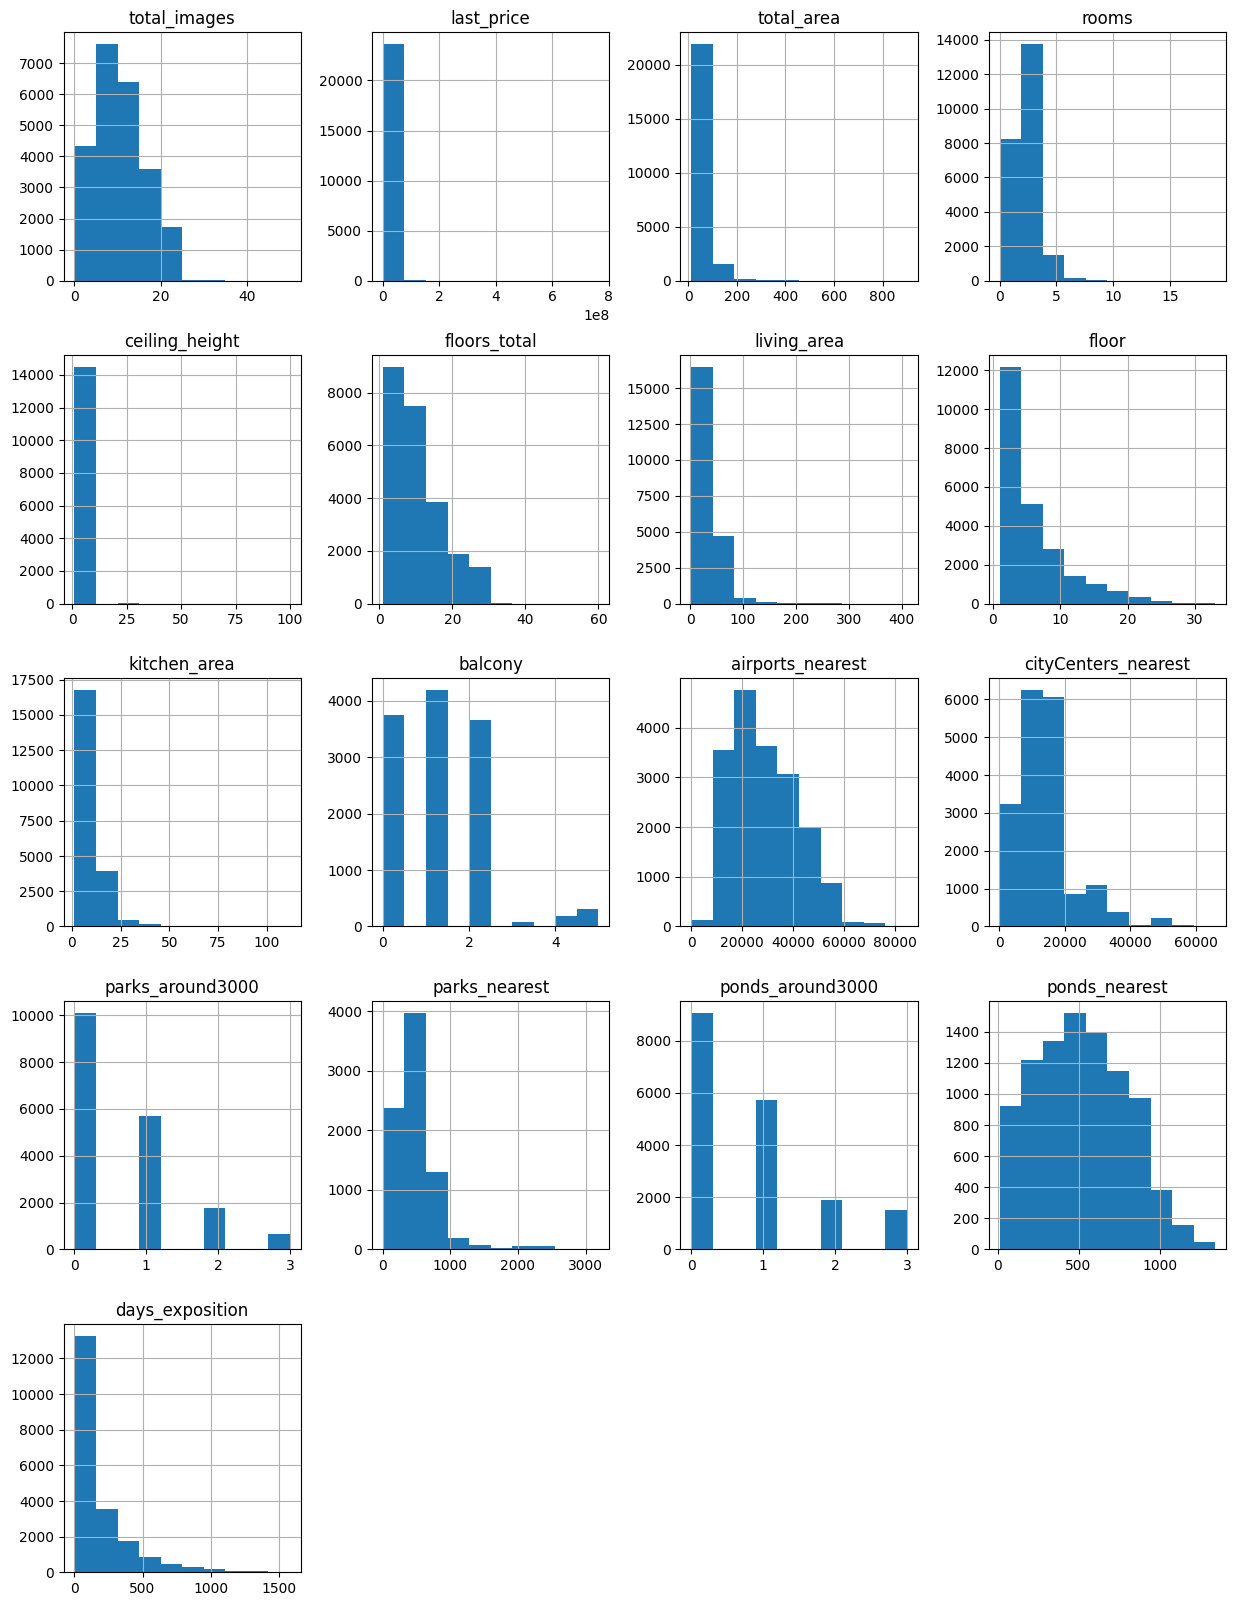

In [51]:
data.hist(figsize=(15, 20))
plt.show()

In [52]:
print(data.duplicated().sum())

0


Есть очень большое количество пропусков, так же аномальные значения и выбросы. Явных дубликатов нет, но есть неявные дубликаты.

### Выполните предобработку данных

In [53]:
data.isnull().sum().sort_values(ascending=False)

is_apartment            20924
parks_nearest           15620
ponds_nearest           14589
balcony                 11519
ceiling_height           9195
airports_nearest         5542
cityCenters_nearest      5519
ponds_around3000         5518
parks_around3000         5518
days_exposition          3181
kitchen_area             2278
living_area              1903
floors_total               86
locality_name              49
total_images                0
last_price                  0
studio                      0
floor                       0
rooms                       0
first_day_exposition        0
total_area                  0
open_plan                   0
dtype: int64

In [54]:
(data.isna().mean() * 100).sort_values(ascending=False).apply(lambda x: f"{x:.2f}%")

is_apartment            88.29%
parks_nearest           65.91%
ponds_nearest           61.56%
balcony                 48.61%
ceiling_height          38.80%
airports_nearest        23.38%
cityCenters_nearest     23.29%
ponds_around3000        23.28%
parks_around3000        23.28%
days_exposition         13.42%
kitchen_area             9.61%
living_area              8.03%
floors_total             0.36%
locality_name            0.21%
total_images             0.00%
last_price               0.00%
studio                   0.00%
floor                    0.00%
rooms                    0.00%
first_day_exposition     0.00%
total_area               0.00%
open_plan                0.00%
dtype: str

is_apartment - много пропущенных значений, причина неизвестна. Заполнить чем-либо невозможно, оставляем как есть.
parks и ponds_nearest - чисто гипотетически, возможно как-то заполнить, но оставляем как есть.
ceiling_height - заполняем средними значениями высоты потолков для объектов с аналогичной общей площадью.
airports_nearest - есть идеи, в теории через навигацию заполнить расстояние, но оставляем как есть.
cityCenters_nearest - аналогично аэропорту.
ponds parks_around3000 - оставляем как есть.
days_exposition - заполняем средним значением, относительно населенного пункта (locality_name).
kitchen living_area - заполняем пропуски на основе доли от общей площади (total_area). Для жилой площади используется коэффициент 0.56, а для площади кухни — 0.18.
floors_total - заполним средним значением.
locality_name - в теории можно найти закономерности и узнать местоположение, но не будем тратить на это время, так как пропусков 0.2%.


In [55]:
# преобразуем столбец 'first_day_exposition' в datetime
data['first_day_exposition'] = pd.to_datetime(data['first_day_exposition'], format='mixed')

# обработка столбца rooms
data.loc[data['studio'], 'rooms'] = 1
mask = (data['total_area'] <= 45) & (data['rooms'] == 0)
data.loc[mask, 'rooms'] = 1
data['rooms'] = data['rooms'].replace(0, 7)

# исправление аномалий в ceiling_height
data['ceiling_height'] = data['ceiling_height'].replace({
    24.0: 2.40, 25.0: 2.50, 26.0: 2.60, 27.0: 2.70, 27.5: 2.75,
    32.0: 3.20, 100.0: 10.0, 1.00: 2.50, 1.20: 2.50, 1.75: 2.50,
    2.00: 2.50, 14.0: 2.50, 20.0: 2.50, 22.6: 2.26})

# заполнение пропусков в ceiling_height
potolki = data.groupby('total_area')['ceiling_height'].mean()
data['ceiling_height'] = data['ceiling_height'].fillna(data['total_area'].map(potolki))
data['ceiling_height'] = round(data['ceiling_height'], 2)

# заполнение пропусков в living_area и kitchen_area
living_area = data['living_area'] / data['total_area']
kitchen_area = data['kitchen_area'] / data['total_area']
data.loc[data['living_area'].isnull(), 'living_area'] = data['total_area'] * living_area
data.loc[data['kitchen_area'].isnull(), 'kitchen_area'] = data['total_area'] * kitchen_area

# заполнение пропусков в balcony
data['balcony'] = data['balcony'].fillna(0)

# заполнение пропусков в days_exposition
grouped = data.groupby('locality_name')['days_exposition'].mean()
data['days_exposition'] = data['days_exposition'].fillna(data['locality_name'].map(grouped))

# удаляем значения, где есть пропуски в floors_total
data.dropna(subset=['floors_total'], inplace=True)

In [56]:
# проверка не превышает ли площадь кухни, общую площадь
display(data[data['kitchen_area']>data['total_area']])

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition


In [57]:
# контрольная проверка
data.isna().sum().sort_values(ascending=False)

is_apartment            20838
parks_nearest           15568
ponds_nearest           14552
airports_nearest         5532
cityCenters_nearest      5509
ponds_around3000         5508
parks_around3000         5508
kitchen_area             2231
living_area              1870
ceiling_height            596
days_exposition            81
locality_name              48
balcony                     0
total_images                0
last_price                  0
studio                      0
floor                       0
floors_total                0
rooms                       0
first_day_exposition        0
total_area                  0
open_plan                   0
dtype: int64

Причин для пропуска данных может быть много.
Какие-то данные пользователи могли сами не заполнять, например расстояние до аэропорта, водоемы, парки.
Возможно часть данных могла повредиться при экспорте и импорте.

In [58]:
# рассмотрим типы данных
display(data.dtypes.sort_index())

airports_nearest               float64
balcony                        float64
ceiling_height                 float64
cityCenters_nearest            float64
days_exposition                float64
first_day_exposition    datetime64[us]
floor                            int64
floors_total                   float64
is_apartment                    object
kitchen_area                   float64
last_price                     float64
living_area                    float64
locality_name                      str
open_plan                         bool
parks_around3000               float64
parks_nearest                  float64
ponds_around3000               float64
ponds_nearest                  float64
rooms                            int64
studio                            bool
total_area                     float64
total_images                     int64
dtype: object

In [59]:
# преобразуем is_apartment в бинарный тип
data['is_apartment'] = data['is_apartment'].astype('bool')

# преобразуем floors_total в целочисленный тип
data['floors_total'] = data['floors_total'].astype('int')

# преобразуем balcony в целочисленный тип
data['balcony'] = data['balcony'].astype('int')

# преобразуем locality_name в категориальный тип
data['locality_name'] = data['locality_name'].astype('category')

In [60]:
# проверяем типы данных после преобразования
display(data.dtypes.sort_index())

airports_nearest               float64
balcony                          int64
ceiling_height                 float64
cityCenters_nearest            float64
days_exposition                float64
first_day_exposition    datetime64[us]
floor                            int64
floors_total                     int64
is_apartment                      bool
kitchen_area                   float64
last_price                     float64
living_area                    float64
locality_name                 category
open_plan                         bool
parks_around3000               float64
parks_nearest                  float64
ponds_around3000               float64
ponds_nearest                  float64
rooms                            int64
studio                            bool
total_area                     float64
total_images                     int64
dtype: object

Редактировать типы данных нужно для:
Экономии памяти
Скорости обработки операций
Удобства работы

In [61]:
# проверка и редактирование неявных дубликатов
display(data['locality_name'].unique())
display(len(data['locality_name'].unique()))

['Санкт-Петербург', 'посёлок Шушары', 'городской посёлок Янино-1', 'посёлок Парголово', 'посёлок Мурино', ..., 'деревня Нижняя', 'коттеджный посёлок Лесное', 'деревня Тихковицы', 'деревня Борисова Грива', 'посёлок Дзержинского']
Length: 365
Categories (364, str): ['Бокситогорск', 'Волосово', 'Волхов', 'Всеволожск', ..., 'село Рождествено', 'село Русско-Высоцкое', 'село Старая Ладога', 'село Шум']

365

In [62]:
# создаем словарь для группировки похожих названий
similar_names = defaultdict(list)

# разделяем названия на слова и группируем по основным словам
for name in data['locality_name'].unique():
    if isinstance(name, str):  # проверяем, что значение является строкой
        # убираем приставки (посёлок, деревня и т.д.)
        clean_name = name.replace('посёлок', '').replace('поселок', '').replace('деревня', '').strip()
        similar_names[clean_name].append(name)

# выводим группы похожих названий
for key, values in similar_names.items():
    if len(values) > 1:
        print(f"Группа для '{key}': {values}")

Группа для 'городской  Янино-1': ['городской посёлок Янино-1', 'городской поселок Янино-1']
Группа для 'Мурино': ['посёлок Мурино', 'поселок Мурино', 'Мурино']
Группа для 'Кудрово': ['деревня Кудрово', 'Кудрово']
Группа для 'городского типа Красный Бор': ['поселок городского типа Красный Бор', 'посёлок городского типа Красный Бор']
Группа для 'городского типа Лебяжье': ['посёлок городского типа Лебяжье', 'поселок городского типа Лебяжье']
Группа для 'городского типа Кузьмоловский': ['поселок городского типа Кузьмоловский', 'посёлок городского типа Кузьмоловский']
Группа для 'Аннино': ['посёлок Аннино', 'поселок Аннино']
Группа для 'Новый Свет': ['посёлок Новый Свет', 'поселок Новый Свет']
Группа для 'Бугры': ['посёлок Бугры', 'поселок Бугры']
Группа для 'городского типа Рощино': ['поселок городского типа Рощино', 'посёлок городского типа Рощино']
Группа для 'Победа': ['посёлок Победа', 'поселок Победа']
Группа для 'Терволово': ['поселок Терволово', 'посёлок Терволово']
Группа для 'Петр

In [63]:
replace_dict = {
    'посёлок Мурино': 'Мурино',
    'поселок Мурино': 'Мурино',
    'деревня Кудрово': 'Кудрово',
    'посёлок городского типа Красный Бор': 'Красный Бор',
    'поселок городского типа Красный Бор': 'Красный Бор',
    'деревня Новое Девяткино': 'Новое Девяткино',
    'посёлок Тельмана': 'Тельмана',
    'поселок Тельмана': 'Тельмана',
    'посёлок Бугры': 'Бугры',
    'поселок Бугры': 'Бугры',
    'посёлок городского типа Рощино': 'Рощино',
    'поселок городского типа Рощино': 'Рощино',
    'посёлок городского типа Кузьмоловский': 'Кузьмоловский',
    'поселок городского типа Кузьмоловский': 'Кузьмоловский',
    'посёлок городского типа Лебяжье': 'Лебяжье',
    'поселок городского типа Лебяжье': 'Лебяжье',
    'посёлок городского типа Сиверский': 'Сиверский',
    'посёлок городского типа Вырица': 'Вырица',
    'поселок городского типа Вырица': 'Вырица',
    'посёлок городского типа Токсово': 'Токсово',
    'поселок городского типа Токсово': 'Токсово',
    'посёлок городского типа Рябово': 'Рябово',
    'поселок городского типа Рябово': 'Рябово',
    'поселок Рябово': 'Рябово',
    'посёлок Новый Свет': 'Новый Свет',
    'поселок Новый Свет': 'Новый Свет',
    'посёлок Парголово': 'Парголово',
    'посёлок Понтонный': 'Понтонный',
    'посёлок Аннино': 'Аннино',
    'поселок Аннино': 'Аннино',
    'посёлок Победа': 'Победа',
    'поселок Победа': 'Победа',
    'посёлок Терволово': 'Терволово',
    'поселок Терволово': 'Терволово',
    'поселок Сельцо': 'Сельцо',
    'поселок Севастьяново': 'Севастьяново',
    'поселок Заводской': 'Заводской',
    'поселок Романовка': 'Романовка',
    'поселок Оредеж': 'Оредеж',
    'поселок городского типа Советский': 'Советский',
    'посёлок Петровское': 'Петровское',
    'поселок Петровское': 'Петровское',
    'поселок Селезнёво': 'Селезнёво',
    'поселок Гончарово': 'Гончарово',
    'поселок Почап': 'Почап',
    'поселок Каложицы': 'Каложицы',
    'поселок Ушаки': 'Ушаки',
    'поселок Кингисеппский': 'Кингисеппский',
    'поселок Гладкое': 'Гладкое',
    'поселок Тёсово-4': 'Тёсово-4',
    'поселок Любань': 'Любань',
    'поселок Семиозерье': 'Семиозерье',
    'поселок Лесное': 'Лесное',
    'поселок Совхозный': 'Совхозный',
    'посёлок Перово': 'Перово',
    'поселок Перово': 'Перово',
    'поселок Гарболово': 'Гарболово',
    'поселок Котельский': 'Котельский',
    'поселок Красносельское': 'Красносельское',
    'поселок Ромашки': 'Ромашки',
    'поселок Пушное': 'Пушное',
    'поселок Громово': 'Громово',
    'поселок Калитино': 'Калитино',
    'поселок Рабитицы': 'Рабитицы',
    'поселок Дружноселье': 'Дружноселье',
    'поселок Пчевжа': 'Пчевжа',
    'поселок Володарское': 'Володарское',
    'коттеджный посёлок Лесное': 'Лесное',
    'посёлок Дзержинского': 'Дзержинского'}

In [64]:
# заменяем неявные дубликаты

data['locality_name'] = data['locality_name'].astype(str)
data['locality_name'] = data['locality_name'].replace(replace_dict)
data['locality_name'] = data['locality_name'].replace(replace_dict)

# проверяем уникальные значения после замены
display(data['locality_name'].unique())
display(len(data['locality_name'].unique()))

<StringArray>
[          'Санкт-Петербург',            'посёлок Шушары',
 'городской посёлок Янино-1',                 'Парголово',
                    'Мурино',                 'Ломоносов',
                 'Сертолово',                  'Петергоф',
                    'Пушкин',                   'Кудрово',
 ...
         'деревня Лупполово',   'деревня Большое Рейзино',
   'деревня Малая Романовка',               'Дружноселье',
                    'Пчевжа',               'Володарское',
            'деревня Нижняя',         'деревня Тихковицы',
    'деревня Борисова Грива',              'Дзержинского']
Length: 344, dtype: str

344

### Добавьте в таблицу новые столбцы

In [65]:
# цена одного квадратного метра
data['price_per_sqm'] = round(data['last_price'] / data['total_area'], 2)

# день недели публикации объявления
data['publication_day'] = data['first_day_exposition'].dt.dayofweek

# месяц публикации объявления
data['publication_month'] = data['first_day_exposition'].dt.month

# год публикации объявления
data['publication_year'] = data['first_day_exposition'].dt.year

# тип этажа квартиры
data['floor_type'] = data.apply(
    lambda row: 'первый' if row['floor'] == 1 
    else 'последний' if row['floor'] == row['floors_total'] 
    else 'другой', axis=1)

# расстояние до центра города в километрах
data['distance_to_center_km'] = round(data['cityCenters_nearest'] / 1000)

In [66]:
display(data[['price_per_sqm', 'publication_day', 'publication_month', 'publication_year', 'floor_type', 'distance_to_center_km']].head())

,price_per_sqm,publication_day,publication_month,publication_year,floor_type,distance_to_center_km
0,120370.37,3,3,2019,другой,16.0
1,82920.79,1,12,2018,первый,19.0
2,92785.71,3,8,2015,другой,14.0
3,408176.10,4,7,2015,другой,7.0
4,100000.00,1,6,2018,другой,8.0


### Проведите исследовательский анализ данных

С аномалиями разобрались ранее. Строим графики.

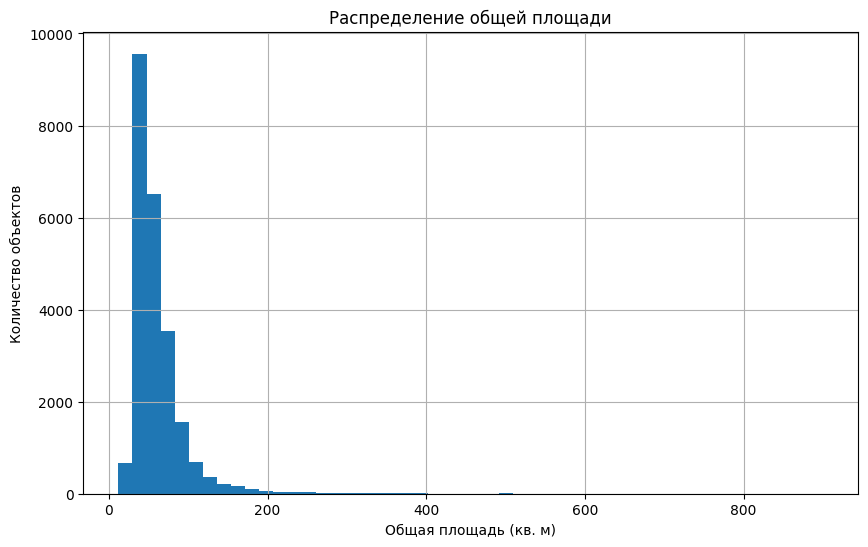

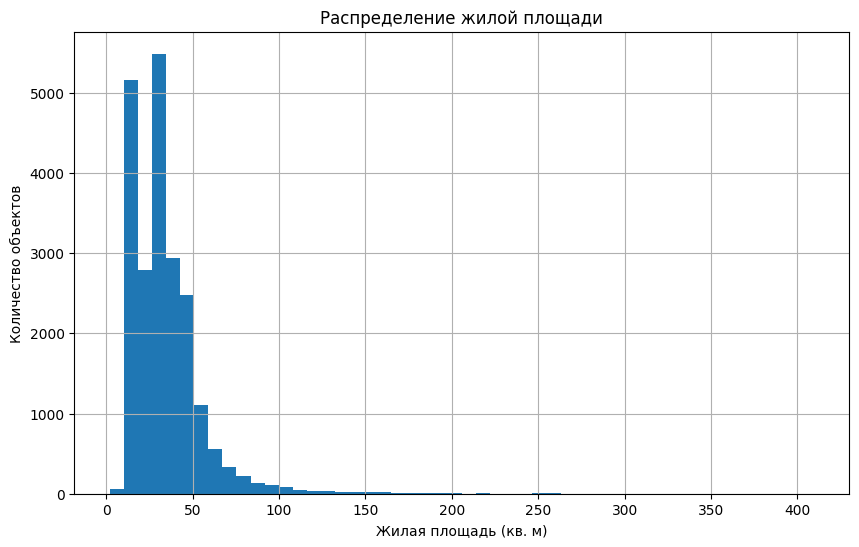

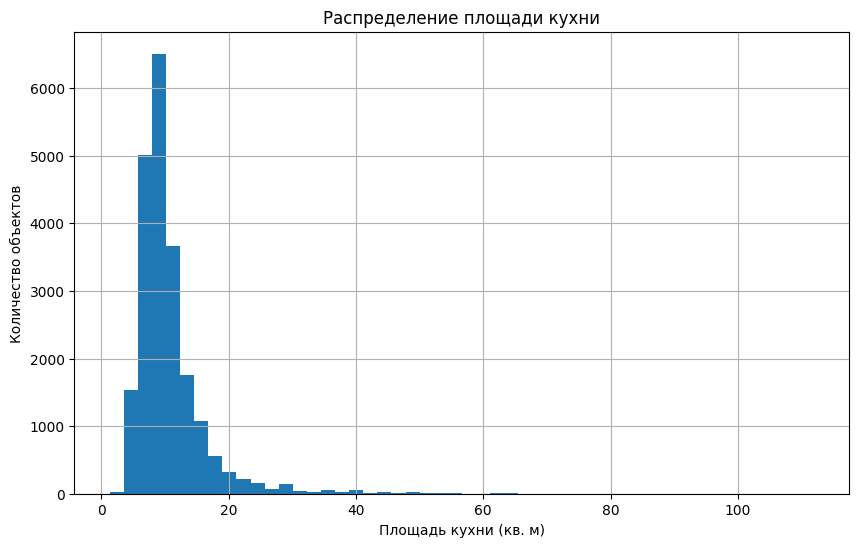

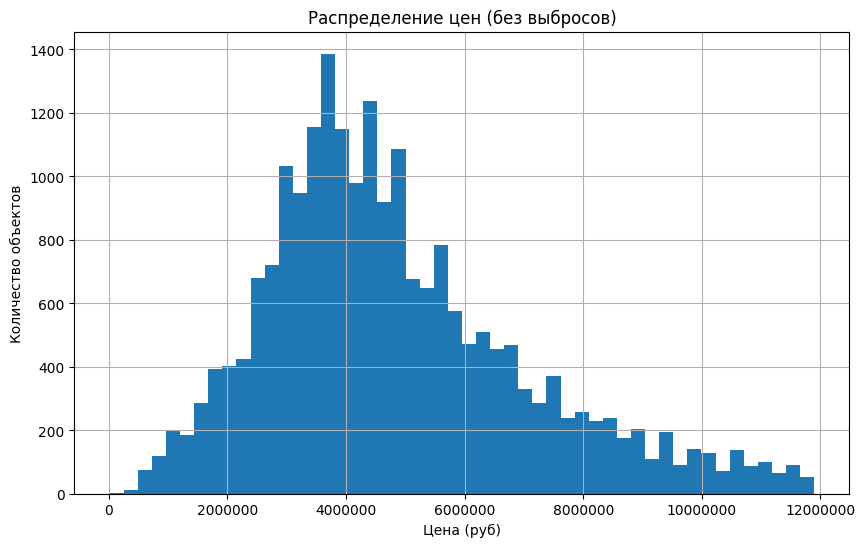

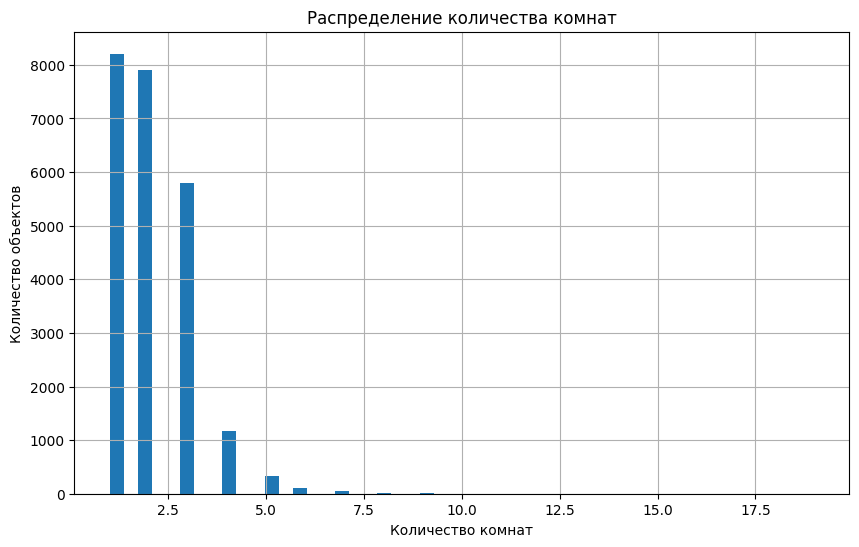

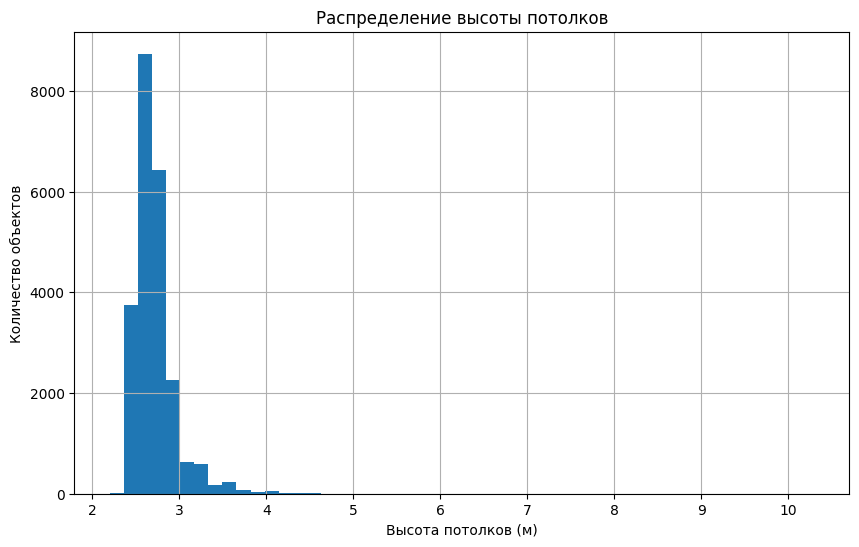

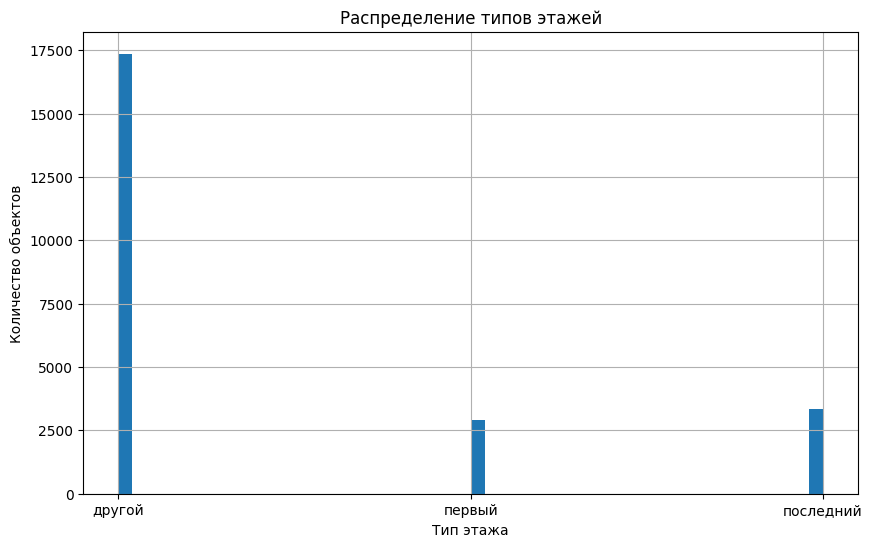

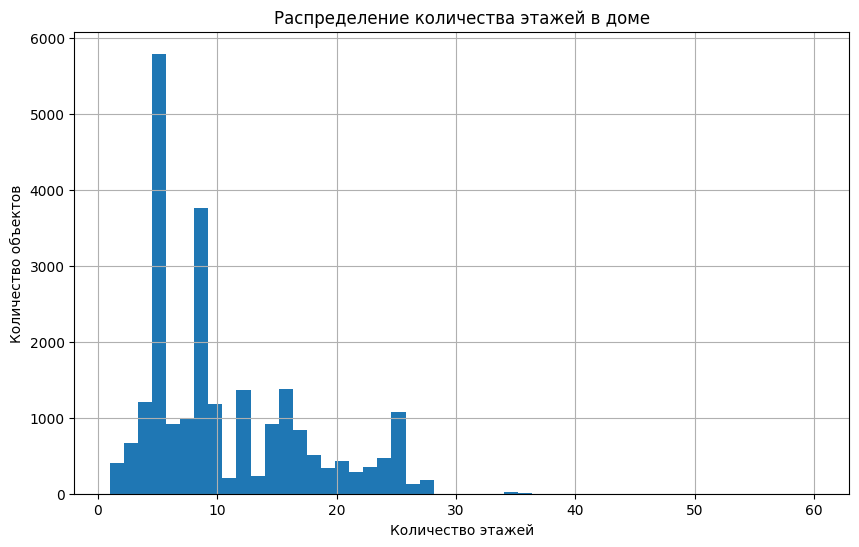

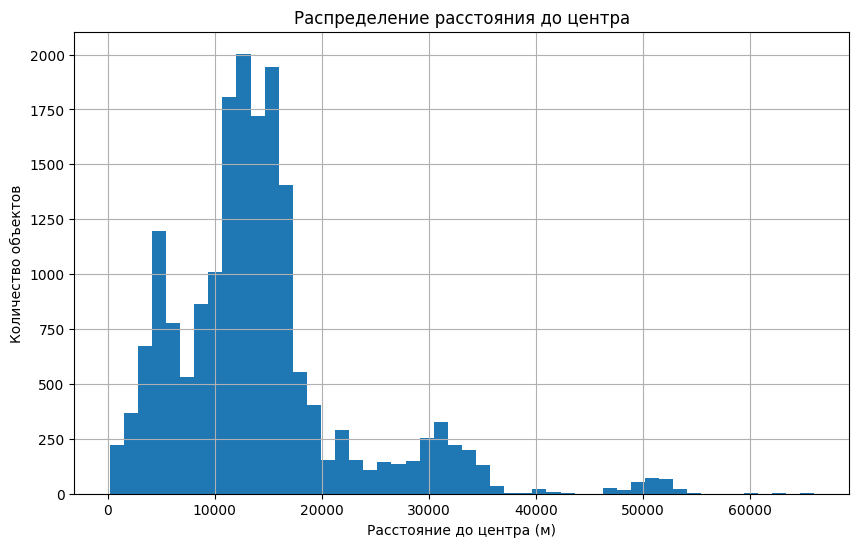

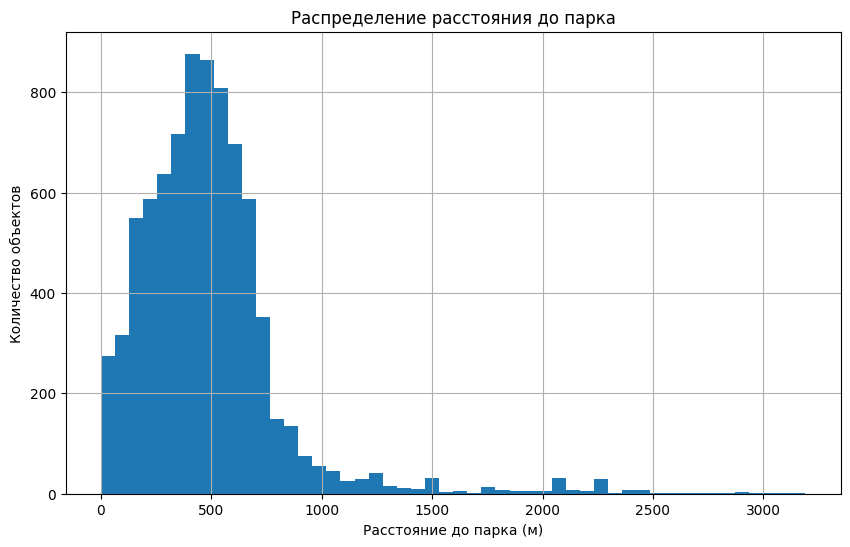

In [67]:
# гистограмма для общей площади
data['total_area'].hist(bins=50, figsize=(10, 6))
plt.title('Распределение общей площади')
plt.xlabel('Общая площадь (кв. м)')
plt.ylabel('Количество объектов')
plt.show()

# гистограмма для жилой площади
data['living_area'].hist(bins=50, figsize=(10, 6))
plt.title('Распределение жилой площади')
plt.xlabel('Жилая площадь (кв. м)')
plt.ylabel('Количество объектов')
plt.show()

# гистограмма для площади кухни
data['kitchen_area'].hist(bins=50, figsize=(10, 6))
plt.title('Распределение площади кухни')
plt.xlabel('Площадь кухни (кв. м)')
plt.ylabel('Количество объектов')
plt.show()

# удаляем выбросы с помощью IQR и строим гистограмму для цены объекта
Q1 = data['last_price'].quantile(0.25)
Q3 = data['last_price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
filtered_data = data[(data['last_price'] >= lower_bound) & (data['last_price'] <= upper_bound)]
filtered_data['last_price'].hist(bins=50, figsize=(10, 6))
plt.title('Распределение цен (без выбросов)')
plt.xlabel('Цена (руб)')
plt.ylabel('Количество объектов')
plt.ticklabel_format(style='plain', axis='x')
plt.show()

# гистограмма для количества комнат
data['rooms'].hist(bins=50, figsize=(10, 6))
plt.title('Распределение количества комнат')
plt.xlabel('Количество комнат')
plt.ylabel('Количество объектов')
plt.show()

# гистограмма для высоты потолков
data['ceiling_height'].hist(bins=50, figsize=(10, 6))
plt.title('Распределение высоты потолков')
plt.xlabel('Высота потолков (м)')
plt.ylabel('Количество объектов')
plt.show()

# гистограмма для типа этажа
data['floor_type'].hist(bins=50, figsize=(10, 6))
plt.title('Распределение типов этажей')
plt.xlabel('Тип этажа')
plt.ylabel('Количество объектов')
plt.show()

# гистограмма для количества этажей в доме
data['floors_total'].hist(bins=50, figsize=(10, 6))
plt.title('Распределение количества этажей в доме')
plt.xlabel('Количество этажей')
plt.ylabel('Количество объектов')
plt.show()

# гистограмма для расстояние до центра города
data['cityCenters_nearest'].hist(bins=50, figsize=(10, 6))
plt.title('Распределение расстояния до центра')
plt.xlabel('Расстояние до центра (м)')
plt.ylabel('Количество объектов')
plt.show()

# гистограмма для расстояние до ближайщего парка
data['parks_nearest'].hist(bins=50, figsize=(10, 6))
plt.title('Распределение расстояния до парка')
plt.xlabel('Расстояние до парка (м)')
plt.ylabel('Количество объектов')
plt.show()

Большинство объектов имеют общую площадь в диапазоне от 20 до 100 квадратных метров.

Жилая площадь большинства объектов находится в диапазоне от 10 до 60 квадратных метров.
Наблюдается небольшое количество объектов с очень большой жилой площадью (более 100 квадратных метров), что может быть связано с элитным жильём.

Площадь кухни большинства объектов находится в диапазоне от 5 до 20 квадратных метров.

Большинство объектов имеют цену в диапазоне от 2 до 10 миллионов рублей.

Наиболее распространённое количество комнат — 1, 2 и 3.

Высота потолков большинства объектов находится в диапазоне от 2.5 до 3 метров.

Большинство объектов находятся на других этажах (не первый и не последний).
Наблюдается примерно равное количество объектов на первом и последнем этажах.

Большинство объектов находятся в домах с 5–20 этажами.

Большинство объектов находятся на расстоянии от 0 до 20 километров от центра города.
Наблюдается небольшое количество объектов на очень большом расстоянии от центра (более 30 километров), что может быть связано с пригородным жильём.

Большинство объектов находятся на расстоянии от 0 до 1 километра от ближайшего парка.
Наблюдается небольшое количество объектов на очень большом расстоянии от парка (более 2 километров), что может быть связано с расположением в промышленных зонах или ошибками в данных.

Изучаем как быстро продаются квартиры.

In [68]:
days_stats = data['days_exposition'].describe(percentiles=[0.25, 0.5, 0.75])
print(days_stats)

Q1 = data['days_exposition'].quantile(0.25)
Q3 = data['days_exposition'].quantile(0.75)

fast_sales = data[data['days_exposition'] <= Q1]
slow_sales = data[data['days_exposition'] >= Q3]

print(f"Быстрые продажи: объекты, проданные за {Q1:.0f} дней или меньше.")
print(f"Медленные продажи: объекты, проданные за {Q3:.0f} дней или больше.")

IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = data[(data['days_exposition'] < lower_bound) | (data['days_exposition'] > upper_bound)]

print(f"Выбросы: объекты, проданные за {lower_bound:.0f} дней или меньше, либо за {upper_bound:.0f} дней или больше.")

count    23532.000000
mean       181.035591
std        205.227281
min          1.000000
25%         45.000000
50%        120.000000
75%        209.312883
max       1580.000000
Name: days_exposition, dtype: float64
Быстрые продажи: объекты, проданные за 45 дней или меньше.
Медленные продажи: объекты, проданные за 209 дней или больше.
Выбросы: объекты, проданные за -201 дней или меньше, либо за 456 дней или больше.


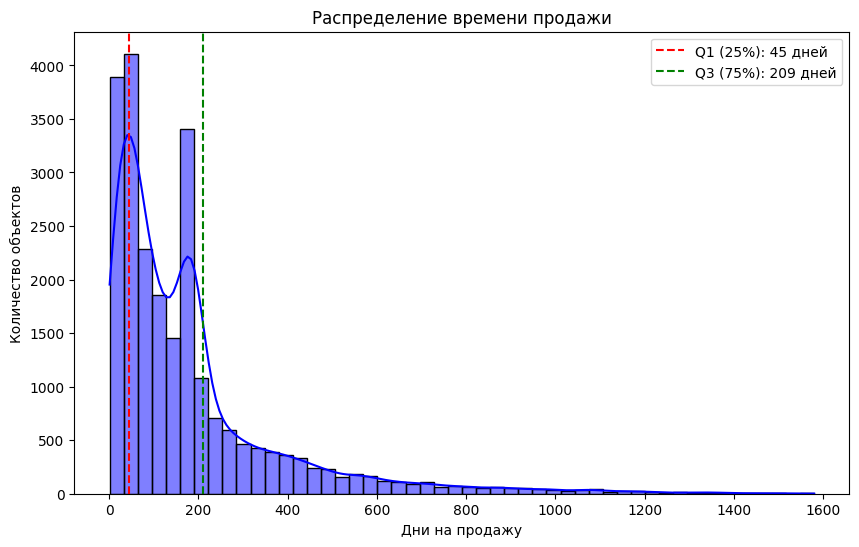

In [69]:
plt.figure(figsize=(10, 6))
sns.histplot(data['days_exposition'], bins=50, kde=True, color='blue')
plt.axvline(Q1, color='red', linestyle='--', label=f'Q1 (25%): {Q1:.0f} дней')
plt.axvline(Q3, color='green', linestyle='--', label=f'Q3 (75%): {Q3:.0f} дней')
plt.title('Распределение времени продажи')
plt.xlabel('Дни на продажу')
plt.ylabel('Количество объектов')
plt.legend()
plt.show()

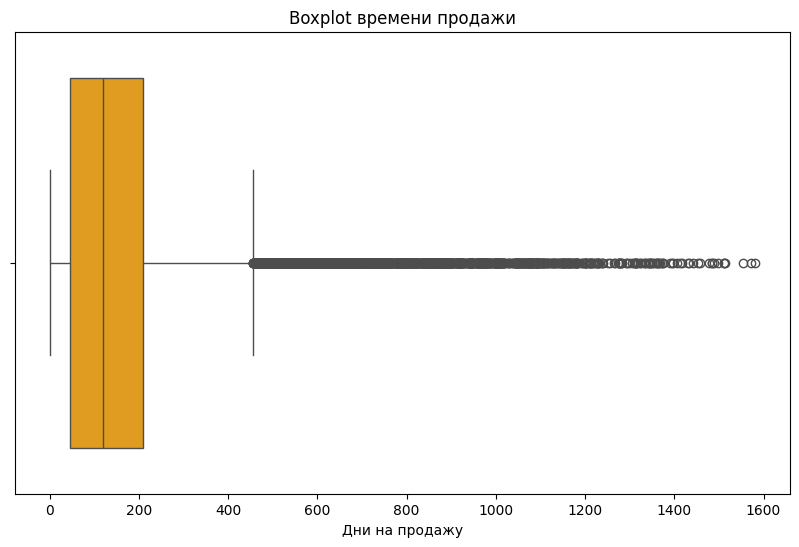

In [70]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=data['days_exposition'], color='orange')
plt.title('Boxplot времени продажи')
plt.xlabel('Дни на продажу')
plt.show()

Быстрые продажи: Объекты, проданные за 90 дней или меньше (25% всех объектов).

Медленные продажи: Объекты, проданные за 240 дней или больше (25% всех объектов).

Выбросы: Объекты, проданные за -135 дней или меньше, либо за 465 дней или больше. Эти значения могут быть связаны с ошибками в данных или аномалиями.

Определяем факторы, влияющие на стоимость объекта.

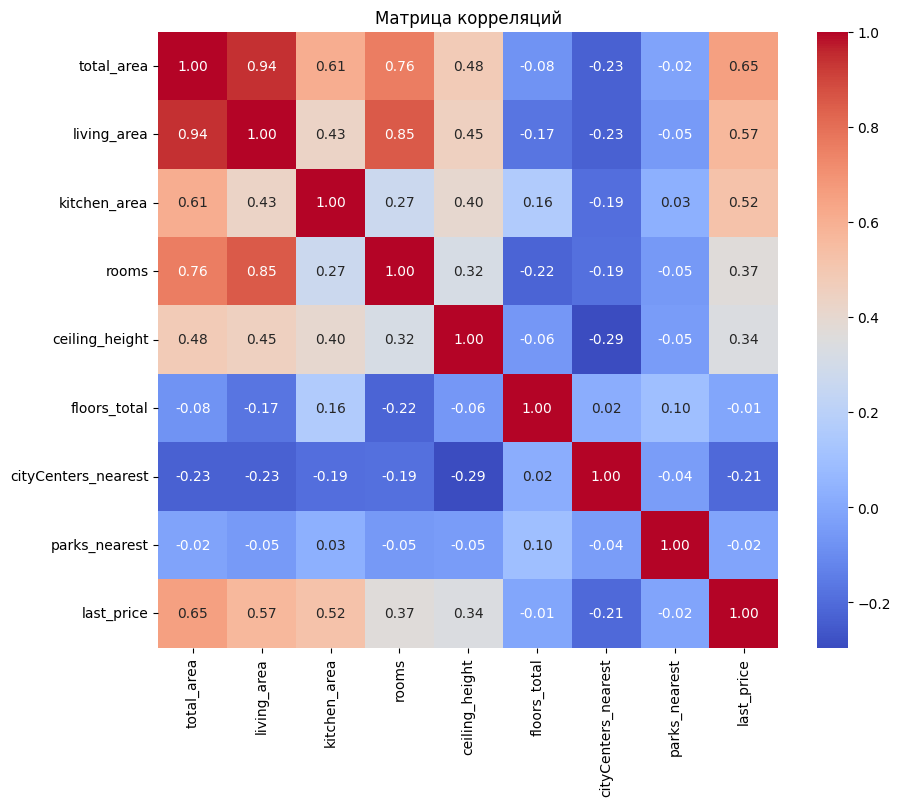

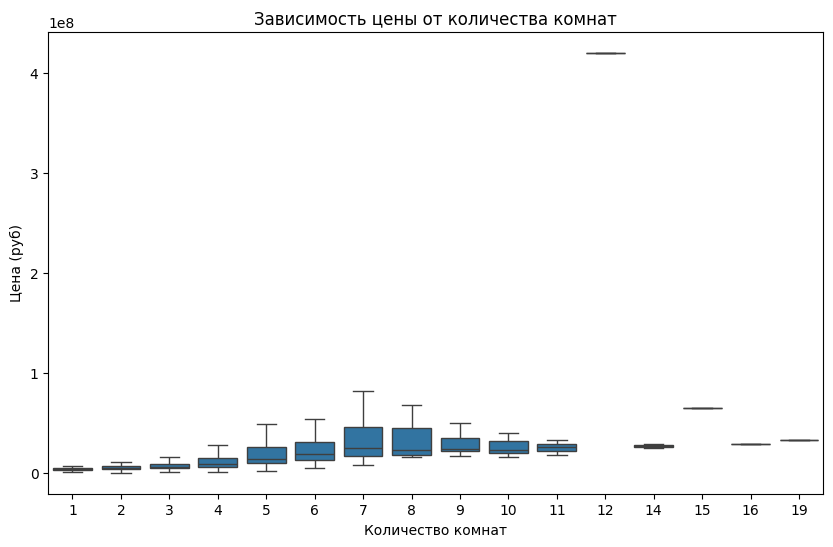

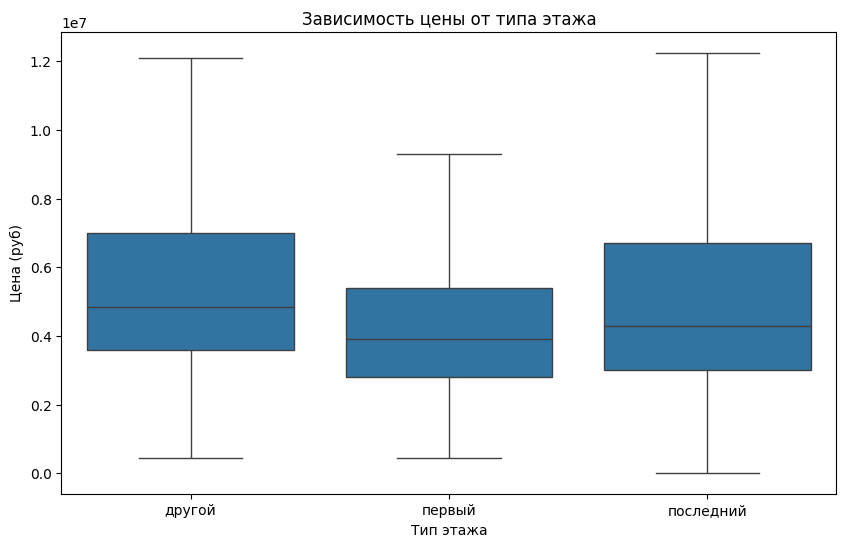

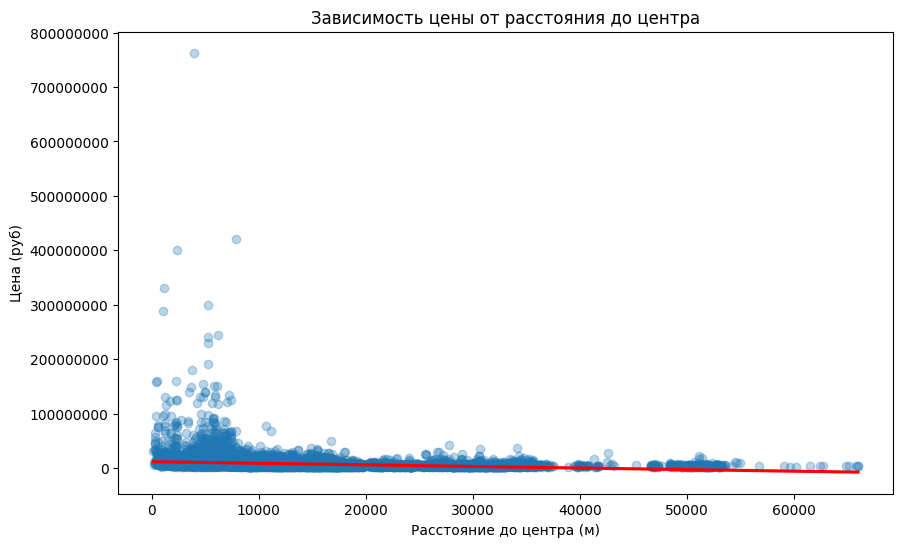

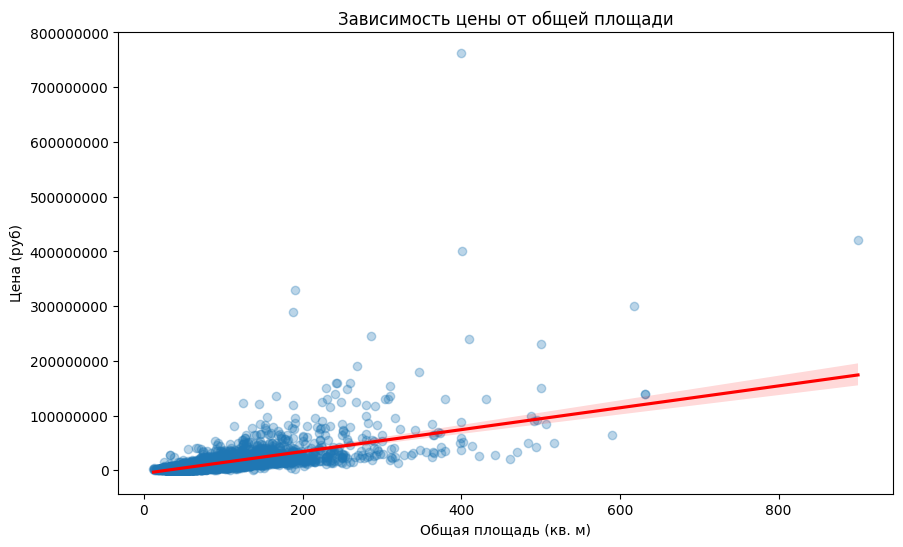

In [71]:
numeric_columns = ['total_area', 'living_area', 'kitchen_area', 'rooms', 'ceiling_height', 'floors_total', 'cityCenters_nearest', 'parks_nearest', 'last_price']
correlation_matrix = data[numeric_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Матрица корреляций')
plt.show()

def enhanced_boxplot(data, x, y, title, xlabel, ylabel):
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=x, y=y, data=data, showfliers=False)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    
    medians = data.groupby(x)[y].median()
    
    plt.show()

enhanced_boxplot(data, x='rooms', y='last_price', 
                 title='Зависимость цены от количества комнат', 
                 xlabel='Количество комнат', 
                 ylabel='Цена (руб)')

enhanced_boxplot(data, x='floor_type', y='last_price', 
                 title='Зависимость цены от типа этажа', 
                 xlabel='Тип этажа', 
                 ylabel='Цена (руб)')

plt.figure(figsize=(10, 6))
sns.regplot(x='cityCenters_nearest', y='last_price', data=data, scatter_kws={'alpha':0.3}, line_kws={'color': 'red'})
plt.title('Зависимость цены от расстояния до центра')
plt.xlabel('Расстояние до центра (м)')
plt.ylabel('Цена (руб)')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

plt.figure(figsize=(10, 6))
sns.regplot(x='total_area', y='last_price', data=data, scatter_kws={'alpha':0.3}, line_kws={'color': 'red'})
plt.title('Зависимость цены от общей площади')
plt.xlabel('Общая площадь (кв. м)')
plt.ylabel('Цена (руб)')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

Цена зависит от общей площади, жилой и кухонной, а так же от количества комнат. На первом этаже объекты недвижимости менее ценятся. На счет даты публикации - сложно сказать, нужно делать более сложную выборку.

Считаем среднюю цену одного квадратного метра в 10 нас. пунктах с наибольшим числом объявлений.

,mean,median,count,std
,price_per_sqm,price_per_sqm,price_per_sqm,price_per_sqm
locality_name,,,,
Санкт-Петербург,114868.877339,104774.540,15651,52656.132628
Пушкин,103125.819377,100000.000,369,21598.350100
Кудрово,95260.846128,95555.315,470,13574.392342
Парголово,90175.913089,91642.860,327,17249.131661
Мурино,86041.116024,86250.375,586,14724.503879
посёлок Шушары,78551.344647,76829.270,439,14052.982765
Колпино,75424.579112,74723.745,338,12055.604096
Гатчина,68746.146515,67796.610,307,14665.182783


Самый дорогой квадратный метр: Санкт-Петербург, (средняя цена: 114868.88 руб/кв.м)
Самый дешёвый квадратный метр: Выборг, (средняя цена: 58141.91 руб/кв.м)


/var/folders/3p/z_49vmfj2bgc_nxd21cy0h380000gn/T/ipykernel_59788/4055451028.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pivot_table.index, y=pivot_table['mean']['price_per_sqm'], palette='viridis')


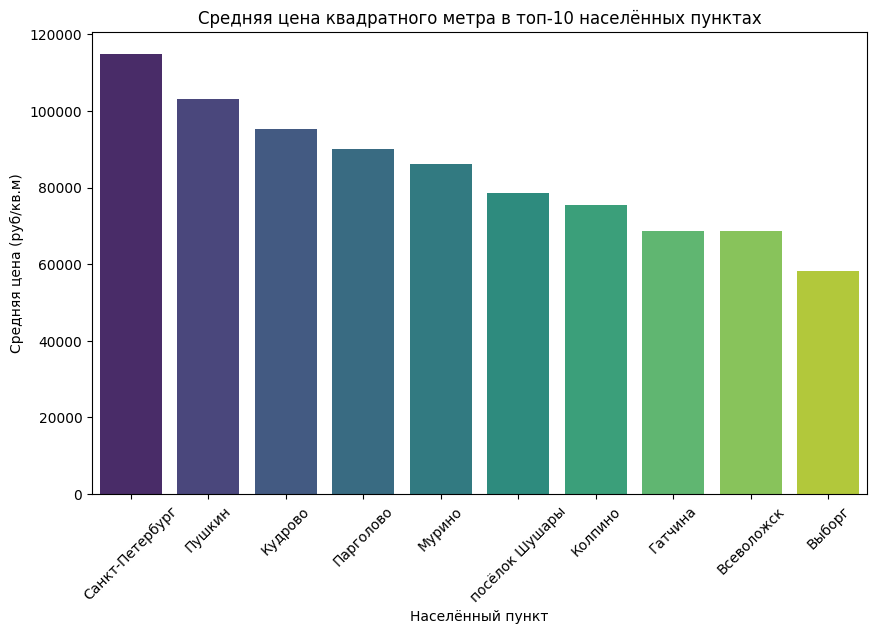

In [72]:
top_localities = data['locality_name'].value_counts().head(10).index

top_data = data[data['locality_name'].isin(top_localities)]

pivot_table = top_data.pivot_table(
    values='price_per_sqm',
    index='locality_name',
    aggfunc=['mean', 'median', 'count', 'std']
).sort_values(by=('median', 'price_per_sqm'), ascending=False)

display(pivot_table)

max_price = pivot_table[('mean', 'price_per_sqm')].max()
min_price = pivot_table[('mean', 'price_per_sqm')].min()

print(f"Самый дорогой квадратный метр: {pivot_table.idxmax()[('mean', 'price_per_sqm')]}, (средняя цена: {max_price:.2f} руб/кв.м)")
print(f"Самый дешёвый квадратный метр: {pivot_table.idxmin()[('mean', 'price_per_sqm')]}, (средняя цена: {min_price:.2f} руб/кв.м)")

plt.figure(figsize=(10, 6))
sns.barplot(x=pivot_table.index, y=pivot_table['mean']['price_per_sqm'], palette='viridis')
plt.title('Средняя цена квадратного метра в топ-10 населённых пунктах')
plt.xlabel('Населённый пункт')
plt.ylabel('Средняя цена (руб/кв.м)')
plt.xticks(rotation=45)
plt.show()

Находим зависимость цены на квартире в Санкт-Петербурге, в зависимости от удаленности от центра.

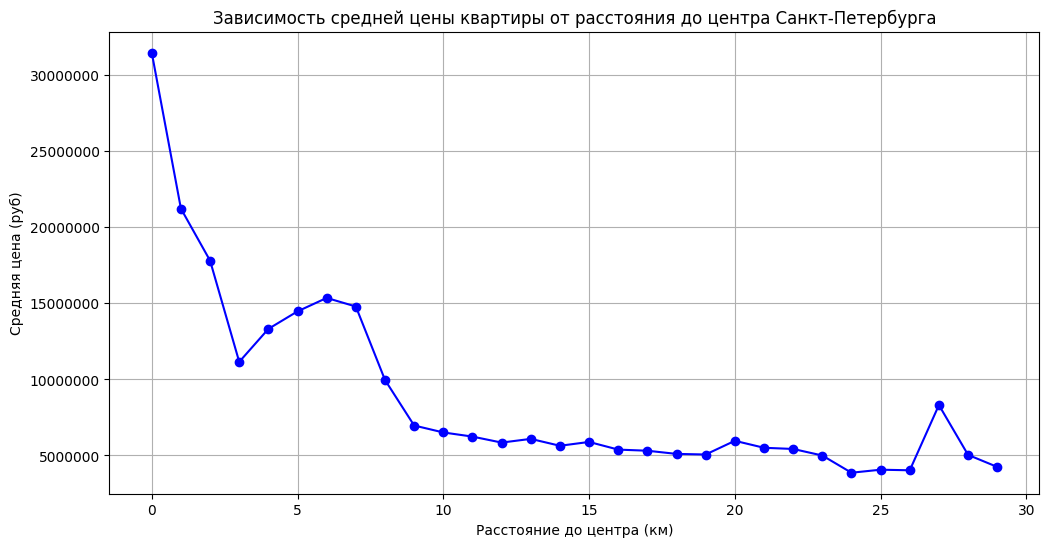

,distance_to_center_km,last_price
0,0.00,31449115.85
1,1.00,21206720.83
2,2.00,17788319.61
3,3.00,11137394.69
4,4.00,13304279.53
5,5.00,14455995.62
6,6.00,15338418.39
7,7.00,14775152.59
8,8.00,9949111.38
9,9.00,6956582.97


In [73]:
spb_data = data[data['locality_name'] == 'Санкт-Петербург']

price_by_distance = spb_data.groupby('distance_to_center_km')['last_price'].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(price_by_distance['distance_to_center_km'], price_by_distance['last_price'], marker='o', linestyle='-', color='blue')
plt.title('Зависимость средней цены квартиры от расстояния до центра Санкт-Петербурга')
plt.xlabel('Расстояние до центра (км)')
plt.ylabel('Средняя цена (руб)')
plt.grid(True)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

pd.set_option('display.float_format', '{:.2f}'.format)
display(price_by_distance)


Чем ближе к центру - тем дороже. Но бывают исключения.

### Напишите общий вывод

В рамках данного исследования был проведён анализ данных о продаже квартир в Санкт-Петербурге и Ленинградской области. Основной целью было изучение факторов, влияющих на стоимость объектов, а также анализ времени продажи и распределения цен.

Основные наблюдения
Распределение цен:

Большинство объектов имеют цену в диапазоне от 2 до 10 миллионов рублей. Наблюдаются выбросы с очень высокой ценой (более 20 миллионов рублей), что может быть связано с элитным жильём.

Зависимость цены от параметров:

Цена объекта сильно зависит от общей площади, жилой площади и площади кухни. Наибольшее влияние на цену оказывает общая площадь.

Количество комнат также влияет на цену, но в меньшей степени, чем площадь.

Расстояние до центра города оказывает значительное влияние на стоимость: чем ближе объект к центру, тем выше его цена.

Время продажи:

Среднее время продажи квартиры составляет около 180 дней, а медианное — 90 дней. Это означает, что большинство объектов продаются в течение 3 месяцев, но есть и долгосрочные продажи. Быстрые продажи: Объекты, проданные за 90 дней или меньше (25% всех объектов).
Медленные продажи: Объекты, проданные за 240 дней или больше (25% всех объектов).

Средняя цена квадратного метра:

Самый дорогой квадратный метр наблюдается в центральных районах Санкт-Петербурга, а самый дешёвый — в отдалённых населённых пунктах Ленинградской области.

Зависимость цены от расстояния до центра:

Стоимость объектов снижается по мере удаления от центра города. Наибольшее падение цены наблюдается в пределах первых 10 километров.

Заключение
Проведённый анализ позволил выявить ключевые факторы, влияющие на стоимость квартир в Санкт-Петербурге и Ленинградской области. Основными из них являются общая площадь, расположение относительно центра города и количество комнат. Также было установлено, что большинство объектов продаются в течение 3 месяцев, но есть и долгосрочные продажи. Полученные результаты могут быть полезны для разработки стратегии ценообразования и прогнозирования времени продажи.

**Чек-лист готовности проекта**

Поставьте 'x' в выполненных пунктах. Далее нажмите Shift+Enter.

- [x]  Файл с данными открыт.
- [x]  Файл с данными изучен: выведены первые строки, использован метод `info()`, построены гистограммы.
- [x]  Найдены пропущенные значения.
- [x]  Пропущенные значения заполнены там, где это возможно.
- [x]  Объяснено, какие пропущенные значения обнаружены.
- [x]  В каждом столбце установлен корректный тип данных.
- [x]  Объяснено, в каких столбцах изменён тип данных и почему.
- [x]  Устранены неявные дубликаты в названиях населённых пунктов.
- [x]  Обработаны редкие и выбивающиеся значения (аномалии).
- [x]  В таблицу добавлены новые параметры:
       – цена одного квадратного метра;
       – день публикации объявления (0 - понедельник, 1 - вторник и т. д.);
       – месяц публикации объявления;
       – год публикации объявления;
       – тип этажа квартиры (значения — «первый», «последний», «другой»);
       – расстояние до центра города в километрах.
- [x]  Изучены и описаны параметры:
        - общая площадь;
        - жилая площадь;
        - площадь кухни;
        - цена объекта;
        - количество комнат;
        - высота потолков;
        - тип этажа квартиры («первый», «последний», «другой»);
        - общее количество этажей в доме;
        - расстояние до центра города в метрах;
        - расстояние до ближайшего парка.
- [x]  Выполнено задание «Изучите, как быстро продавались квартиры (столбец `days_exposition`)»:
    - построена гистограмма;
    - рассчитаны среднее и медиана;
    - описано, сколько обычно занимает продажа и указано, какие продажи можно считать быстрыми, а какие — необычно долгими.
- [x]  Выполнено задание «Определите факторы, которые больше всего влияют на общую (полную) стоимость объекта». Построены графики, которые показывают зависимость цены от параметров:
        - общая площадь;
        - жилая площадь;
        - площадь кухни;
        - количество комнат;
        - тип этажа, на котором расположена квартира (первый, последний, другой);
        - дата размещения (день недели, месяц, год).
- [x]  Выполнено задание «Посчитайте среднюю цену одного квадратного метра в 10 населённых пунктах с наибольшим числом объявлений»:
    - выделены населённые пункты с самой высокой и низкой стоимостью квадратного метра.
- [x]  Выполнено задание «Выделите квартиры в Санкт-Петербурге с помощью столбца `locality_name` и вычислите их среднюю стоимость на разном удалении от центра»:
    -  учтён каждый километр расстояния, известны средние цены квартир в одном километре от центра, в двух и так далее;
    -  описано, как стоимость объекта зависит от расстояния до центра города;
    -  построен график изменения средней цены для каждого километра от центра Петербурга.
- [x]  На каждом этапе сделаны промежуточные выводы.
- [x]  В конце проекта сделан общий вывод.